## Single Perceptron

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import Perceptron
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.read_csv('datasets/placement.csv')
df

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


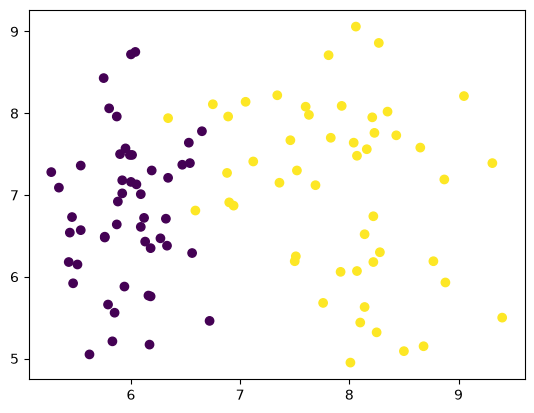

In [3]:
plt.scatter(x=df['cgpa'], y=df['resume_score'], c=df['placed'])
plt.show()

In [4]:
x_train = df.iloc[:,0:2]
y_train = df.iloc[:,2]

In [5]:
P = Perceptron()
P.fit(x_train, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [6]:
P.coef_

array([[ 40.26, -36.  ]])

In [7]:
P.intercept_

array([-25.])

D:\Deep Learning\dl\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


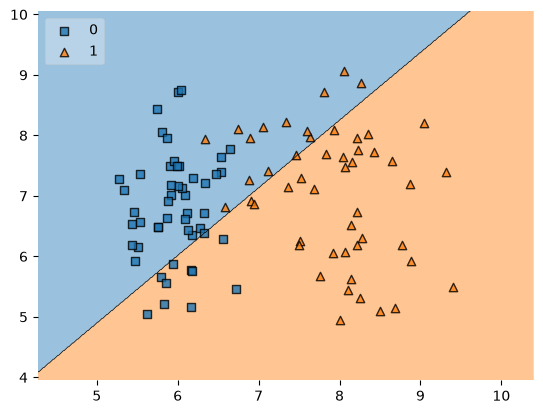

In [8]:
plot_decision_regions(x_train.values, y_train.values, clf=P, legend=2)
plt.show()

## Perceptron Trick

In [34]:
def perceptron(x, y):

    epoch = 10000
    lr = 1
    
    x = np.insert(x, 0, 1, axis=1) # inserting ones at first
    weights = np.ones(x.shape[1])

    for i in range(epoch):
        
        indx = np.random.randint(0, x.shape[0]) # selecting random point
        z = np.dot(x[indx], weights) # sum of weights * x_train        
        y_hat = step(z) # activation function

        weights += lr * (y[indx] - y_hat) * x[indx] # weights update

    return weights[0], weights[1:] # intercept, coef

def step(n):
    return 1 if n>=0 else 0

In [35]:
intercept, coef = perceptron(x_train, y_train)
print(intercept, coef)

-233.0 [ 46.24 -12.35]


In [36]:
m, b = -coef[0]/coef[1], intercept/coef[1]
print(m, b)

3.744129554655911 18.86639676113372


## Perceptron Loss Function and GD

In [54]:
def GD(x, y):

    epoch = 1000
    lr = 0.1
    weights = np.ones(x.shape[1])
    b = 1 

    for _ in range(epoch):
        
        for i in range(x.shape[0]):
            z = np.dot(x[i], weights) + b 

            if z * y[i] < 0:
                weights += (lr * y[i] * x[i])
                b += (lr * y[i])

    return weights, b

In [56]:
weights, bias = GD(x_train.values, y_train.apply(lambda x : -1 if x==0 else 1))
print(weights, bias)

[10.072  0.229] -71.10000000000024


In [59]:
m, b = -weights[0]/weights[1], -bias/weights[1]
print(m, b)

-43.98253275111108 310.48034934507916
